# Resume Screener — Exploratory Data Analysis

This notebook explores the resume dataset to understand:
- Category distribution
- Resume text length statistics
- Most common keywords per category
- Word clouds
- TF-IDF feature importance


In [1]:
import sys
sys.path.insert(0, '..')  # Add project root to path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from src.data_loader import load_raw_dataset
from src.preprocessor import preprocess_series

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 100)

## 1. Load Dataset

In [2]:
df = load_raw_dataset()
print(f'Shape: {df.shape}')
df.head()

[DataLoader] Loaded 962 records | 25 categories
Shape: (962, 2)


,Resume,Category
0,"Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Ja...",Data Science
1,Education Details \r\nMay 2013 to May 2017 B.E UIT-RGPV\r\nData Scientist \r\n\r\nData Scienti...,Data Science
2,"Areas of Interest Deep Learning, Control System Design, Programming in-Python, Electric Machiner...",Data Science
3,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Tableau â¢ SAP HANA SQL â¢ SAP HANA PAL â¢ MS SQL â...,Data Science
4,"Education Details \r\n MCA YMCAUST, Faridabad, Haryana\r\nData Science internship \r\n\r\n\r...",Data Science


## 2. Category Distribution

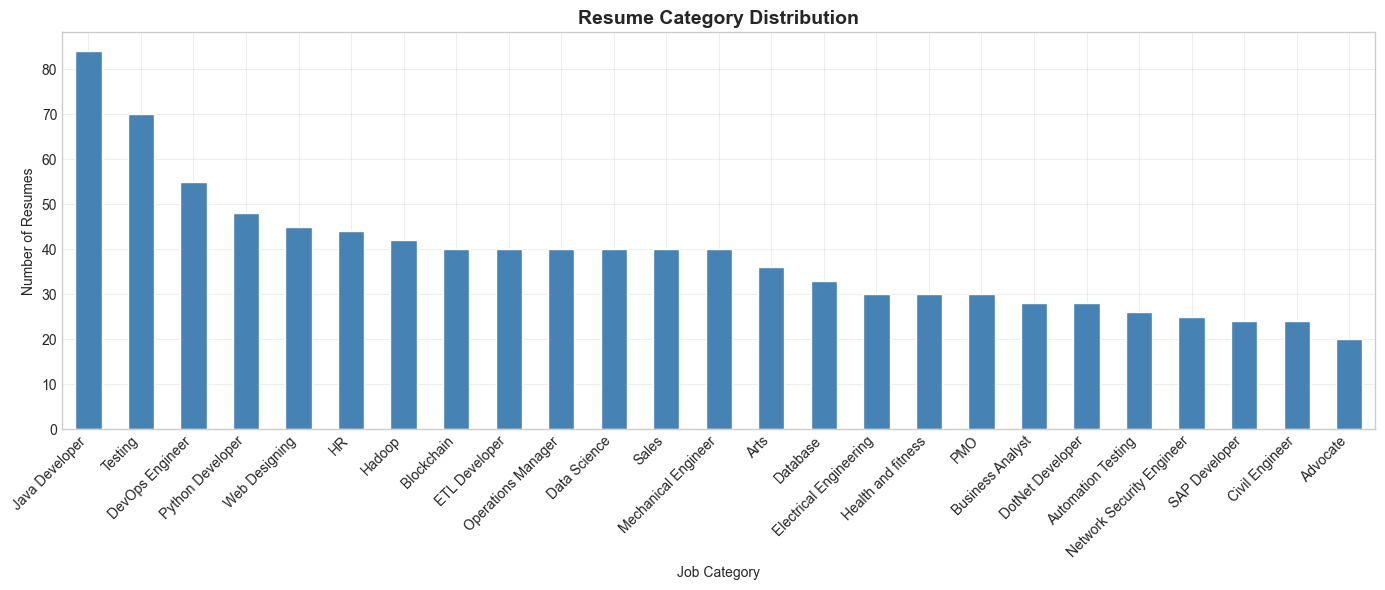

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64


In [3]:
counts = df['Category'].value_counts()

fig, ax = plt.subplots(figsize=(14, 6))
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Resume Category Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Job Category')
ax.set_ylabel('Number of Resumes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(counts)

## 3. Resume Length Analysis

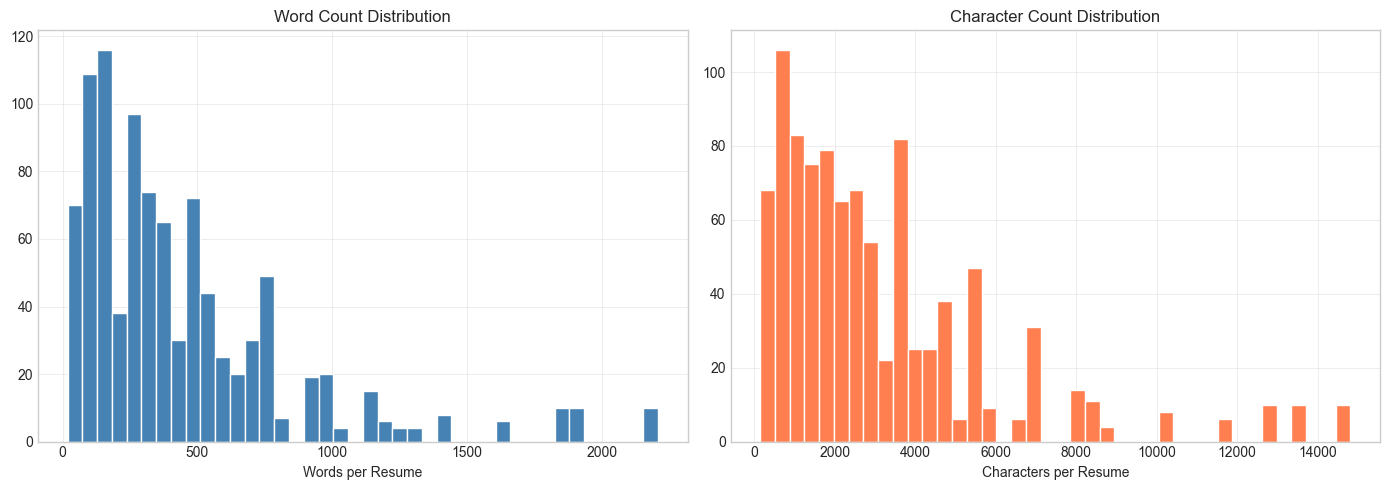

       word_count  char_count
count       962.0       962.0
mean        450.0      3160.0
std         416.0      2887.0
min          19.0       141.0
25%         166.0      1217.0
50%         329.0      2355.0
75%         589.0      4074.0
max        2209.0     14816.0


In [4]:
df['word_count'] = df['Resume'].apply(lambda x: len(x.split()))
df['char_count'] = df['Resume'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Words per Resume')

axes[1].hist(df['char_count'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Character Count Distribution')
axes[1].set_xlabel('Characters per Resume')

plt.tight_layout()
plt.show()

print(df[['word_count', 'char_count']].describe().round(0))

## 4. Word Cloud — All Resumes

Preprocessing text for word cloud...


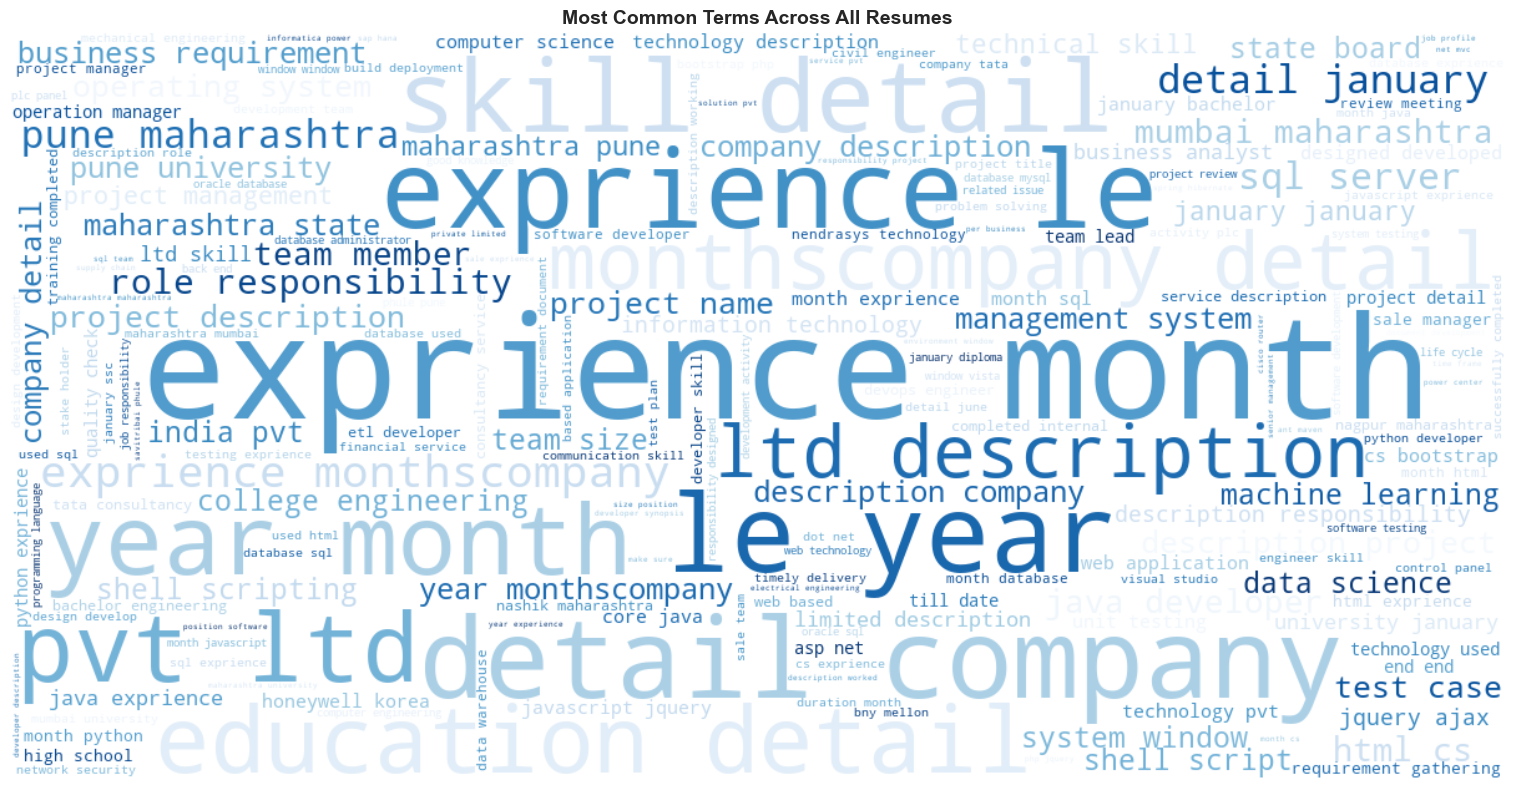

In [5]:
print('Preprocessing text for word cloud...')
df['cleaned'] = preprocess_series(df['Resume'])

all_text = ' '.join(df['cleaned'])
wc = WordCloud(width=1200, height=600, background_color='white',
               colormap='Blues', max_words=200).generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Terms Across All Resumes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Category-Specific Word Cloud

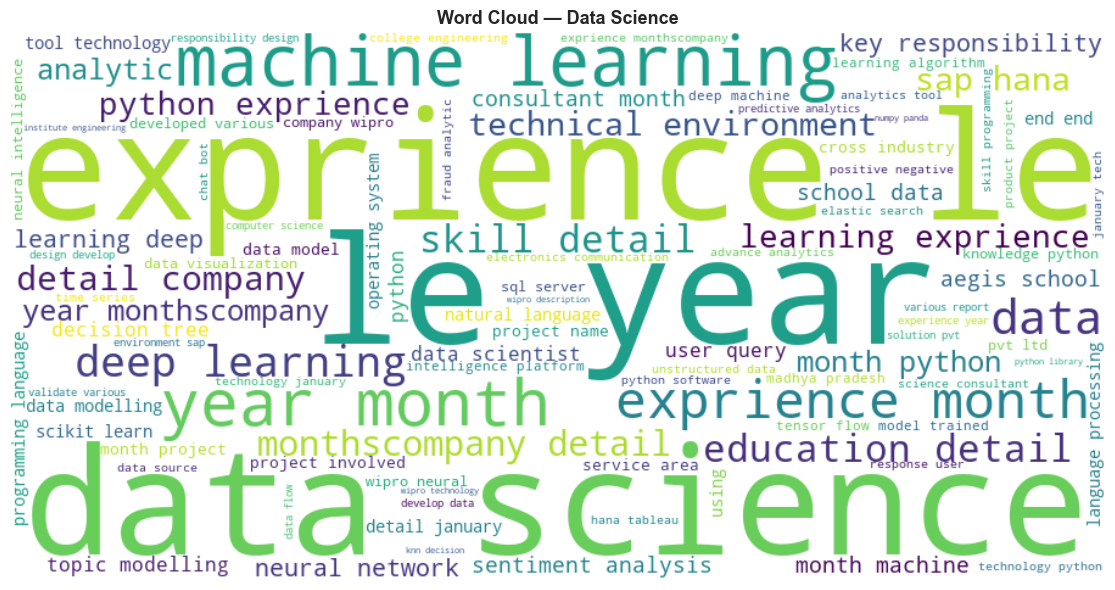

In [6]:
# Pick any category to explore
TARGET_CATEGORY = 'Data Science'

subset = df[df['Category'] == TARGET_CATEGORY]['cleaned']
text = ' '.join(subset)

wc = WordCloud(width=900, height=450, background_color='white',
               colormap='viridis', max_words=100).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title(f'Word Cloud — {TARGET_CATEGORY}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. TF-IDF Top Features per Category

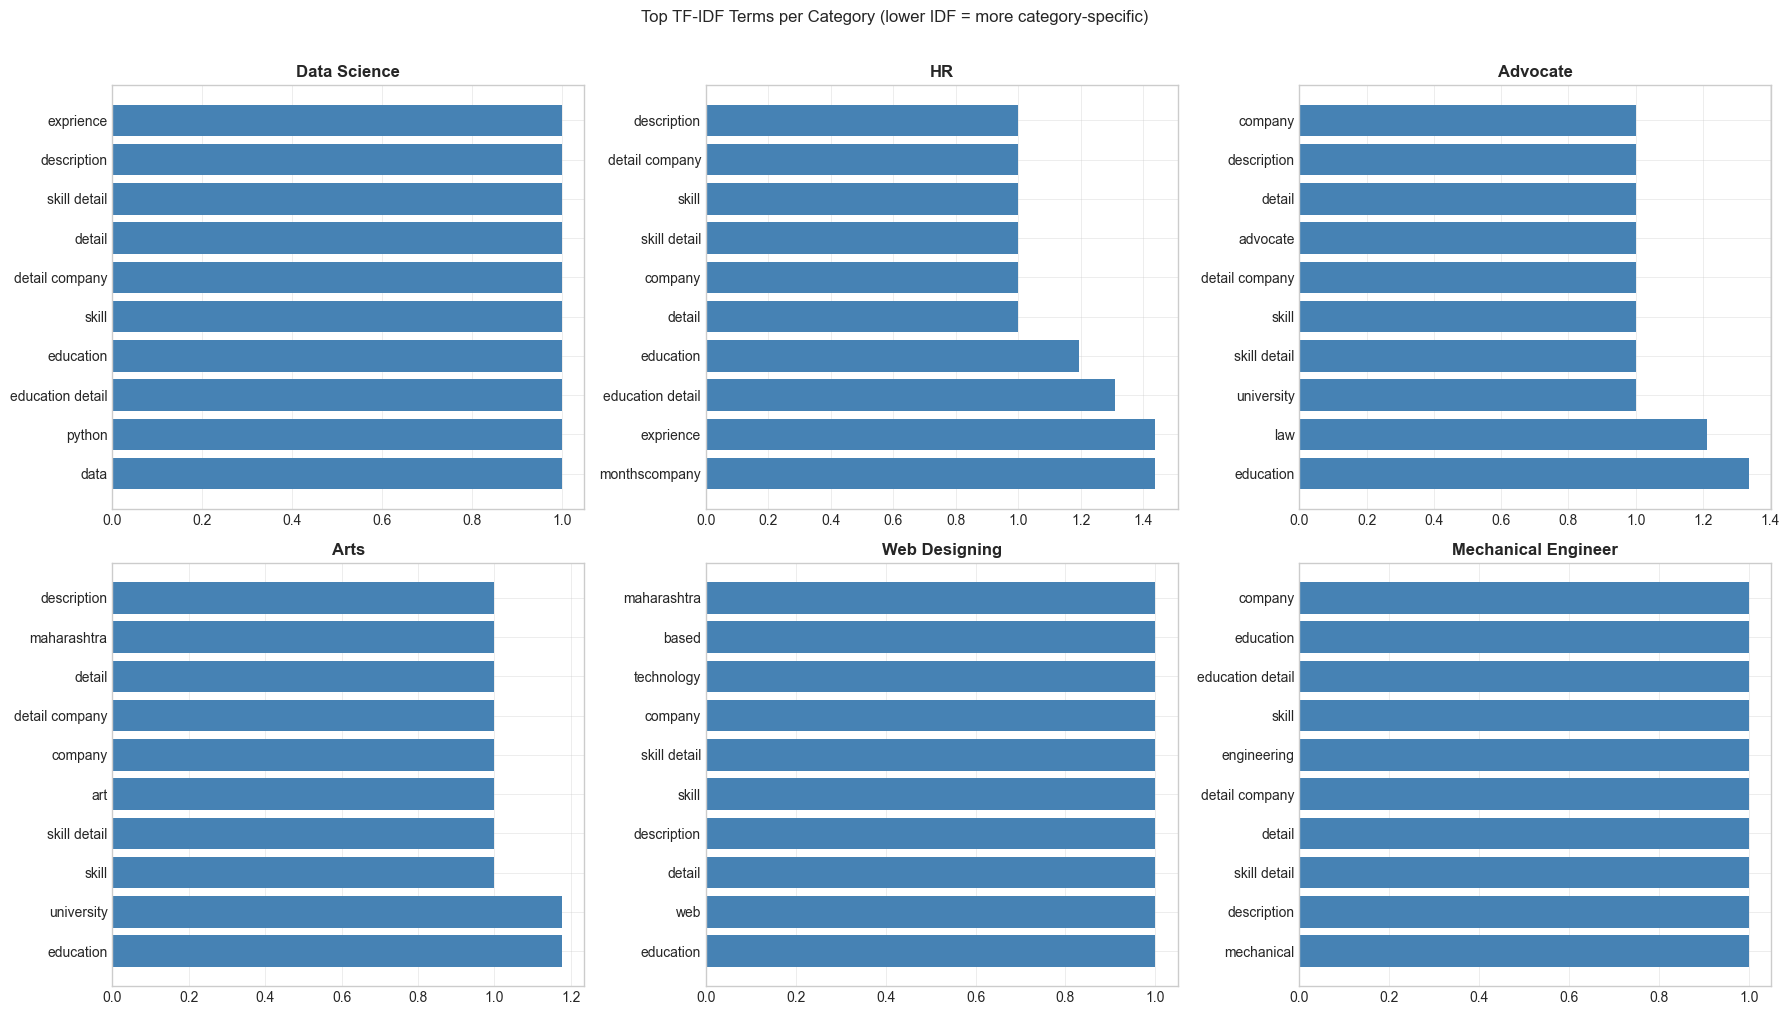

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

TOP_N = 10
categories_to_show = df['Category'].unique()[:6]  # Show first 6

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, cat in enumerate(categories_to_show):
    cat_text = df[df['Category'] == cat]['cleaned'].tolist()
    tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
    tfidf.fit(cat_text)
    
    scores = tfidf.idf_
    # Lower IDF = more common in this category
    feature_names = np.array(tfidf.get_feature_names_out())
    top_idx = np.argsort(scores)[:TOP_N]
    top_terms = feature_names[top_idx]
    top_scores = scores[top_idx]
    
    axes[idx].barh(top_terms, top_scores, color='steelblue')
    axes[idx].set_title(cat, fontweight='bold')
    axes[idx].invert_yaxis()

plt.suptitle('Top TF-IDF Terms per Category (lower IDF = more category-specific)', 
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()